# Multi-Robot Path Planning using A* Algorithms

This notebook implements:
- **Phase 1**: Independent A* (baseline)
- **Phase 2**: Conflict Detection System
- **Phase 3**: Cooperative A* with reservations
- **Phase 4**: Testing & Validation
- **Phase 5**: Integration wrapper

In [ ]:
# ========================================
# IMPORTS
# ========================================
import heapq
import time
from collections import defaultdict
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Set

In [3]:
# ========================================
# NODE CLASS (from Issam_Laribi)
# ========================================
class Node:
    """Represents a node in the search tree"""

    def __init__(self, position, parent=None, g=0, h=0):
        """Initialize a node for pathfinding
        
        Args:
            position (tuple): (x, y) coordinate
            parent (Node): Parent node in the path
            g (float): Cost from start to this node
            h (float): Heuristic cost from this node to goal (Manhattan distance)
        """
        self.position = position
        self.parent = parent
        self.g = g
        self.h = h
        self.f = g + h

    def __lt__(self, other):
        """Compare nodes for priority queue (min-heap by f value)"""
        return self.f < other.f

    def __eq__(self, other):
        """Check if two nodes represent the same position"""
        return self.position == other.position

    def __hash__(self):
        """Hash function for use in sets and dicts"""
        return hash(self.position)

    def reconstruct_path(self):
        """Reconstruct path from start to this node
        
        Returns:
            List[tuple]: Path as list of (x, y) coordinates
        """
        path = []
        current = self
        while current is not None:
            path.append(current.position)
            current = current.parent
        return list(reversed(path))

In [ ]:
# ========================================
# GRID ENVIRONMENT (from Issam_Laribi)
# ========================================
class GridEnvironment:
    """Represents the grid map"""

    def __init__(self, filename=None):
        """Load grid from file or create empty grid"""
        self.grid = []
        self.height = 0
        self.width = 0
        
        if filename:
            self.load_from_file(filename)

    def load_from_file(self, filename):
        """Load grid from file"""
        self.grid = []
        max_width = 0
        with open(filename, 'r') as f:
            for line in f:
                row = []
                for char in line.strip():
                    if char == '.':
                        row.append(True)
                    elif char == 'T':
                        row.append(False)
                max_width = max(max_width, len(row))
                self.grid.append(row)
        self.height = len(self.grid)
        self.width = max_width if self.height > 0 else 0
        for row in self.grid:
            if len(row) < self.width:
                row.extend([False] * (self.width - len(row)))

    def is_valid_position(self, x, y):
        """Check if position is within grid bounds"""
        return 0 <= x < self.width and 0 <= y < self.height

    def is_walkable(self, x, y):
        """Check if position is walkable (not obstacle)"""
        return self.is_valid_position(x, y) and self.grid[y][x]

    def get_neighbors(self, x, y):
        """Get adjacent cells (4-directional)"""
        directions = [(0, 1), (1, 0), (0, -1), (-1, 0)]
        neighbors = []

        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if self.is_walkable(nx, ny):
                neighbors.append((nx, ny))

        return neighbors

    def manhattan_distance(self, pos1, pos2):
        """Calculate Manhattan distance between two positions"""
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

In [5]:
# ========================================
# ROBOT CLASS (from Issam_Laribi)
# ========================================
class Robot:
    """Represents a single robot in the warehouse"""
    def __init__(self, robot_id, grid, start_pos, goal_pos, color='blue'):
        """Initialize robot with grid reference
        
        Args:
            robot_id (int): Unique identifier for robot
            grid (GridEnvironment): The grid this robot moves in
            start_pos (tuple): Starting (x, y) position
            goal_pos (tuple): Goal (x, y) position
            color (str): Robot color for visualization
        """
        self.robot_id = robot_id
        self.grid = grid
        self.start_pos = start_pos
        self.goal_pos = goal_pos
        self.current_pos = start_pos
        self.path = []
        self.path_index = 0
        self.color = color

    def get_current_position(self):
        """Get current position"""
        return self.current_pos

    def get_goal_position(self):
        """Get goal position"""
        return self.goal_pos

    def get_start_position(self):
        """Get start position"""
        return self.start_pos

    def set_path(self, path):
        """Store path for robot"""
        self.path = path
        self.path_index = 0

    def get_path(self):
        """Get stored path"""
        return self.path

    def get_position_at_time(self, time_step):
        """Get robot's position at a specific time step"""
        if time_step < len(self.path):
            return self.path[time_step]
        else:
            return self.path[-1] if self.path else self.current_pos

    def is_at_goal(self):
        """Check if robot reached goal"""
        return self.current_pos == self.goal_pos

In [6]:
# ========================================
# PHASE 1: INDEPENDENT A* 
# ========================================

class IndependentAStarPlanner:
    """
    Independent A* planner - each robot is planned independently without awareness of others.
    This serves as the baseline for comparison.
    """

    def __init__(self, grid: GridEnvironment):
        self.grid = grid
        self._path_cache = {}
        self._cache_hits = 0
        self._cache_misses = 0

    def _get_cache_key(self, start: Tuple[int, int], goal: Tuple[int, int], obstacles: Set) -> str:
        """Generate cache key from start, goal, and obstacle configuration."""
        obs_hash = frozenset(obstacles) if obstacles else frozenset()
        return f"{start}-{goal}-{obs_hash}"

    def run_independent_astar(self, robot: Robot, obstacles: Set = None) -> List[Tuple[int, int]]:
        """Run A* for a single robot."""
        if obstacles is None:
            obstacles = set()

        start = robot.start_pos
        goal = robot.goal_pos

        if not self.grid.is_walkable(*start) or not self.grid.is_walkable(*goal):
            return None

        if start == goal:
            return [start]

        open_set = []
        start_node = Node(start, g=0, h=self.grid.manhattan_distance(start, goal))
        heapq.heappush(open_set, start_node)

        came_from = {}
        g_score = {start: 0}
        closed_set = set()

        while open_set:
            current = heapq.heappop(open_set)

            if current.position in closed_set:
                continue
            closed_set.add(current.position)

            if current.position == goal:
                return current.reconstruct_path()

            neighbors = self.grid.get_neighbors(*current.position)
            neighbors.append(current.position)
            for neighbor in neighbors:
                if neighbor in obstacles:
                    continue

                tentative_g = current.g + 1

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    g_score[neighbor] = tentative_g
                    h = self.grid.manhattan_distance(neighbor, goal)
                    neighbor_node = Node(neighbor, parent=current, g=tentative_g, h=h)
                    came_from[neighbor_node] = current
                    heapq.heappush(open_set, neighbor_node)

        return None

    def plan_all_robots(self, robots: List[Robot]) -> Dict[int, List[Tuple[int, int]]]:
        """Plan paths for all robots with caching and early exit optimization."""
        paths = {}
        
        # Early exit: check if robots have spatially separated start/goal positions
        if len(robots) > 1:
            avg_distance = sum(
                self.grid.manhattan_distance(r.start_pos, r.goal_pos) for r in robots
            ) / len(robots)
            # If average path length is much larger than separation, conflicts unlikely
            spatial_conflict_risk = all(
                self._estimate_conflict_risk(robots[i], robots[j])
                for i in range(len(robots))
                for j in range(i+1, len(robots))
            )
        
        for robot in robots:
            cache_key = self._get_cache_key(robot.start_pos, robot.goal_pos, None)
            if cache_key in self._path_cache:
                self._cache_hits += 1
                paths[robot.robot_id] = self._path_cache[cache_key].copy()
                continue
            self._cache_misses += 1
            path = self.run_independent_astar(robot)
            if path:
                self._path_cache[cache_key] = path.copy()
            paths[robot.robot_id] = path
        
        return paths

    def _estimate_conflict_risk(self, robot1: Robot, robot2: Robot) -> bool:
        """Estimate if two robots are likely to conflict based on spatial separation."""
        # Check if their path corridors are far apart
        dist = abs(robot1.start_pos[0] - robot2.start_pos[0]) + abs(robot1.start_pos[1] - robot2.start_pos[1])
        return dist < 5  # Risk if robots are within 5 cells of each other

    def get_cache_stats(self) -> Dict:
        """Get cache performance statistics."""
        total = self._cache_hits + self._cache_misses
        hit_rate = self._cache_hits / total if total > 0 else 0
        return {'hits': self._cache_hits, 'misses': self._cache_misses, 'hit_rate': hit_rate}

    def clear_cache(self):
        """Clear the path cache."""
        self._path_cache.clear()
        self._cache_hits = 0
        self._cache_misses = 0

In [7]:
# ========================================
# PHASE 2: CONFLICT DETECTION SYSTEM
# ========================================

class ConflictDetector:
    """
    Conflict detection system that identifies three types of collisions between robot paths.
    
    Conflict Types:
    1. Vertex Conflict: Two robots occupy same position at same time step
    2. Edge Conflict: Two robots traverse same edge in same direction    """

    def __init__(self):
        self.conflicts = []

    def detect_vertex_conflicts(self, paths: Dict) -> List[Dict]:
        """Detect vertex conflicts - two robots at same position at same time."""
        conflicts = []
        robot_ids = list(paths.keys())
        max_time = max(len(path) for path in paths.values())

        for t in range(max_time):
            positions_at_t = {}
            for robot_id in robot_ids:
                path = paths[robot_id]
                if path and t < len(path):
                    positions_at_t[robot_id] = path[t]

            position_to_robots = defaultdict(list)
            for robot_id, pos in positions_at_t.items():
                position_to_robots[pos].append(robot_id)

            for pos, robots in position_to_robots.items():
                if len(robots) > 1:
                    conflicts.append({
                        'type': 'vertex',
                        'robot1': robots[0],
                        'robot2': robots[1],
                        'time': t,
                        'position': pos
                    })
        return conflicts

    def detect_edge_conflicts(self, paths: Dict) -> List[Dict]:
        """Detect edge conflicts - two robots traverse same edge in same direction."""
        conflicts = []
        robot_ids = list(paths.keys())
        max_time = max(len(path) for path in paths.values()) - 1

        for t in range(max_time):
            edges_at_t = {}
            for robot_id in robot_ids:
                path = paths[robot_id]
                if path and t + 1 < len(path):
                    edge = (path[t], path[t + 1])
                    edges_at_t[(edge, robot_id)] = edge

            edge_to_robots = defaultdict(list)
            for (edge, robot_id), edge_pos in edges_at_t.items():
                edge_to_robots[edge_pos].append(robot_id)

            for edge, robots in edge_to_robots.items():
                if len(robots) > 1:
                    conflicts.append({
                        'type': 'edge',
                        'robot1': robots[0],
                        'robot2': robots[1],
                        'time': t,
                        'edge': edge
                    })
        return conflicts

    
    def detect_swap_conflicts(self, paths: Dict) -> List[Dict]:
        """Detect swap conflicts - two robots exchanging positions in one timestep."""
        conflicts = []
        robot_ids = list(paths.keys())
        max_time = max(len(path) for path in paths.values()) - 1

        for t in range(max_time):
            for i, robot1_id in enumerate(robot_ids):
                for robot2_id in robot_ids[i+1:]:
                    path1 = paths[robot1_id]
                    path2 = paths[robot2_id]
                    if not path1 or not path2:
                        continue
                    if t + 1 >= len(path1) or t + 1 >= len(path2):
                        continue
                    pos1_t = path1[t]
                    pos1_t1 = path1[t + 1]
                    pos2_t = path2[t]
                    pos2_t1 = path2[t + 1]
                    if pos1_t == pos2_t1 and pos2_t == pos1_t1:
                        conflicts.append({
                            'type': 'swap',
                            'robot1': robot1_id,
                            'robot2': robot2_id,
                            'time': t,
                            'positions': (pos1_t, pos2_t)
                        })
        return conflicts

    def detect_edge_swap_conflicts(self, paths: Dict) -> List[Dict]:
        """Detect edge-swap conflicts - two robots traversing same edge in opposite directions."""
        conflicts = []
        robot_ids = list(paths.keys())
        max_time = max(len(path) for path in paths.values()) - 1

        for t in range(max_time):
            for i, robot1_id in enumerate(robot_ids):
                for robot2_id in robot_ids[i+1:]:
                    path1 = paths[robot1_id]
                    path2 = paths[robot2_id]
                    if not path1 or not path2:
                        continue
                    if t + 1 >= len(path1) or t + 1 >= len(path2):
                        continue
                    edge1 = (path1[t], path1[t + 1])
                    edge2 = (path2[t], path2[t + 1])
                    if edge1 == edge2[::-1]:
                        conflicts.append({
                            'type': 'edge-swap',
                            'robot1': robot1_id,
                            'robot2': robot2_id,
                            'time': t,
                            'edge': edge1
                        })
        return conflicts

    def detect_following_conflicts(self, paths: Dict) -> List[Dict]:
        """Detect following conflicts - Robot A moves into Robot B's previous position."""
        conflicts = []
        robot_ids = list(paths.keys())
        max_time = max(len(path) for path in paths.values()) - 1

        for t in range(max_time):
            for i, robot1_id in enumerate(robot_ids):
                for robot2_id in robot_ids[i+1:]:
                    path1 = paths[robot1_id]
                    path2 = paths[robot2_id]
                    if not path1 or not path2:
                        continue
                    if t + 1 >= len(path1) or t >= len(path2):
                        continue
                    if path1[t + 1] == path2[t]:
                        conflicts.append({
                            'type': 'following',
                            'robot1': robot1_id,
                            'robot2': robot2_id,
                            'time': t,
                            'position': path2[t]
                        })
        return conflicts

    def get_conflict_report(self, paths: Dict) -> List[Dict]:
        """Get complete conflict report."""
        vertex_conflicts = self.detect_vertex_conflicts(paths)
        edge_conflicts = self.detect_edge_conflicts(paths)
        swap_conflicts = self.detect_swap_conflicts(paths)
        edge_swap_conflicts = self.detect_edge_swap_conflicts(paths)
        following_conflicts = self.detect_following_conflicts(paths)
        self.conflicts = vertex_conflicts + edge_conflicts + swap_conflicts + edge_swap_conflicts + following_conflicts
        return self.conflicts

    def count_conflicts(self, paths: Dict) -> int:
        """Count total number of conflicts."""
        return len(self.get_conflict_report(paths))

    def pad_paths(self, paths: Dict) -> Dict:
        """Pad shorter paths with wait actions at goal."""
        max_time = max(len(path) for path in paths.values()) if paths else 0
        padded_paths = {}

        for robot_id, path in paths.items():
            if path and len(path) > 0:
                goal_pos = path[-1]
                padded_path = path + [goal_pos] * (max_time - len(path))
                padded_paths[robot_id] = padded_path
        return padded_paths

    def build_occupation_map(self, paths: Dict) -> Dict[Tuple, str]:
        """Build time-space occupation map."""
        occupation_map = {}
        padded_paths = self.pad_paths(paths)

        for robot_id, path in padded_paths.items():
            for t, position in enumerate(path):
                occupation_map[(position[0], position[1], t)] = robot_id
        return occupation_map

In [8]:
# ========================================
# PHASE 4: TESTING & VALIDATION
# ========================================

def validate_paths(paths: Dict, grid: GridEnvironment, robots: List[Robot]) -> Tuple[bool, List[str]]:
    """Validate that all paths are valid."""
    errors = []

    for robot in robots:
        path = paths.get(robot.robot_id)

        if path is None or len(path) == 0:
            errors.append(f"Robot {robot.robot_id}: No path found")
            continue

        if path[0] != robot.start_pos:
            errors.append(f"Robot {robot.robot_id}: Path does not start at start position")

        if path[-1] != robot.goal_pos:
            errors.append(f"Robot {robot.robot_id}: Path does not end at goal position")

        for i, pos in enumerate(path):
            if not grid.is_walkable(*pos):
                errors.append(f"Robot {robot.robot_id}: Invalid position {pos} at step {i}")

        for i in range(len(path) - 1):
            dx = abs(path[i+1][0] - path[i][0])
            dy = abs(path[i+1][1] - path[i][1])
            if dx + dy != 1 and dx + dy != 0:
                errors.append(f"Robot {robot.robot_id}: Invalid move from {path[i]} to {path[i+1]}")

    return len(errors) == 0, errors


def count_conflicts(paths: Dict) -> int:
    """Count total number of conflicts."""
    detector = ConflictDetector()
    return detector.count_conflicts(paths)


def calculate_makespan(paths: Dict) -> int:
    """Calculate makespan - maximum path length."""
    valid_paths = [path for path in paths.values() if path]
    return max(len(path) for path in valid_paths) if valid_paths else 0


def calculate_flowtime(paths: Dict) -> int:
    """Calculate flowtime - sum of all path lengths."""
    valid_paths = [path for path in paths.values() if path]
    return sum(len(path) for path in valid_paths) if valid_paths else 0


def measure_plan_time(func) -> Tuple[float, any]:
    """Measure execution time of a function."""
    start_time = time.time()
    result = func()
    elapsed_time = time.time() - start_time
    return elapsed_time, result


def compare_algorithms(grid: GridEnvironment, robots: List[Robot]) -> Dict:
    """Run Independent A* algorithm and analyze results."""
    independent_planner = IndependentAStarPlanner(grid)

    ind_time, ind_paths = measure_plan_time(lambda: independent_planner.plan_all_robots(robots))

    ind_valid, ind_errors = validate_paths(ind_paths, grid, robots)

    results = {
        'independent': {
            'paths': ind_paths,
            'valid': ind_valid,
            'errors': ind_errors,
            'conflicts': count_conflicts(ind_paths),
            'makespan': calculate_makespan(ind_paths),
            'flowtime': calculate_flowtime(ind_paths),
            'plan_time': ind_time
        }
    }

    return results

In [9]:
# ========================================
# PHASE 4: BENCHMARK SUITE & EDGE CASES
# ========================================

def run_benchmark(grid: GridEnvironment, robot_counts: List[int], num_trials: int = 3) -> Dict:
    
    """Run benchmark tests varying number of robots."""
    import random
    results = {'robot_counts': [], 'avg_times': [], 'avg_makespan': [], 'avg_conflicts': []}
    
    for count in robot_counts:
        times, makespans, conflicts = [], [], []
        for _ in range(num_trials):
            robots = []
            for i in range(count):
                start = (random.randint(1, 10), random.randint(1, 10))
                goal = (random.randint(grid.width-11, grid.width-1), random.randint(1, 10))
                robots.append(Robot(i, grid, start, goal))
            
            planner = IndependentAStarPlanner(grid)
            start_time = time.time()
            paths = planner.plan_all_robots(robots)
            elapsed = time.time() - start_time
            
            times.append(elapsed)
            makespans.append(calculate_makespan(paths))
            conflicts.append(ConflictDetector().count_conflicts(paths))
        
        results['robot_counts'].append(count)
        results['avg_times'].append(sum(times)/len(times))
        results['avg_makespan'].append(sum(makespans)/len(makespans))
        results['avg_conflicts'].append(sum(conflicts)/len(conflicts))
    
    return results


def test_edge_cases(grid: GridEnvironment) -> Dict:
    
    """Test edge cases for the planner."""
    results = {}
    planner = IndependentAStarPlanner(grid)
    detector = ConflictDetector()
    
    # Edge case 1: Single robot
    robots = [Robot(0, grid, (5, 5), (10, 10), 'red')]
    paths = planner.plan_all_robots(robots)
    valid, _ = validate_paths(paths, grid, robots)
    results['single_robot'] = {'valid': valid, 'path_len': len(paths.get(0, []))}
    
    # Edge case 2: Same start position
    try:
        robots = [Robot(0, grid, (5, 5), (10, 5), 'red'),
                  Robot(1, grid, (5, 5), (15, 5), 'blue')]
        paths = planner.plan_all_robots(robots)
        valid, _ = validate_paths(paths, grid, robots)
        results['same_start'] = {'valid': valid, 'paths_found': len([p for p in paths.values() if p])}
    except Exception as e:
        results['same_start'] = {'error': str(e)}
    
    # Edge case 3: Same goal position
    robots = [Robot(0, grid, (5, 5), (10, 10), 'red'),
              Robot(1, grid, (15, 15), (10, 10), 'blue')]
    paths = planner.plan_all_robots(robots)
    valid, _ = validate_paths(paths, grid, robots)
    results['same_goal'] = {'valid': valid, 'paths_found': len([p for p in paths.values() if p])}
    
    # Edge case 4: No path (blocked)
    # Use a different grid setup
    results['no_path'] = {'tested': 'configure blocked grid'}
    
    # Edge case 5: Robot in dead-end
    robots = [Robot(0, grid, (5, 5), (3, 5), 'red')]
    paths = planner.plan_all_robots(robots)
    valid, _ = validate_paths(paths, grid, robots)
    results['dead_end'] = {'valid': valid, 'path_len': len(paths.get(0, []))}
    
    return results


# Example usage:
# grid = GridEnvironment('maps/small.txt')
# edge_results = test_edge_cases(grid)
# print(edge_results)


Loaded map: ../widjdane_chouali/grid.txt
Grid size: 184x71
Obstacle cells: 5338
Initialized 10 agents in the maze.

--- Planning Results ---
Time Taken: 0.0616 seconds
Paths successfully calculated: 10 out of 10
Overall Makespan: 231
Overall Flowtime: 1590
Total Conflicts Detected (Since they are independent and unaware): 6

Generating visualization...


IndexError: list index out of range

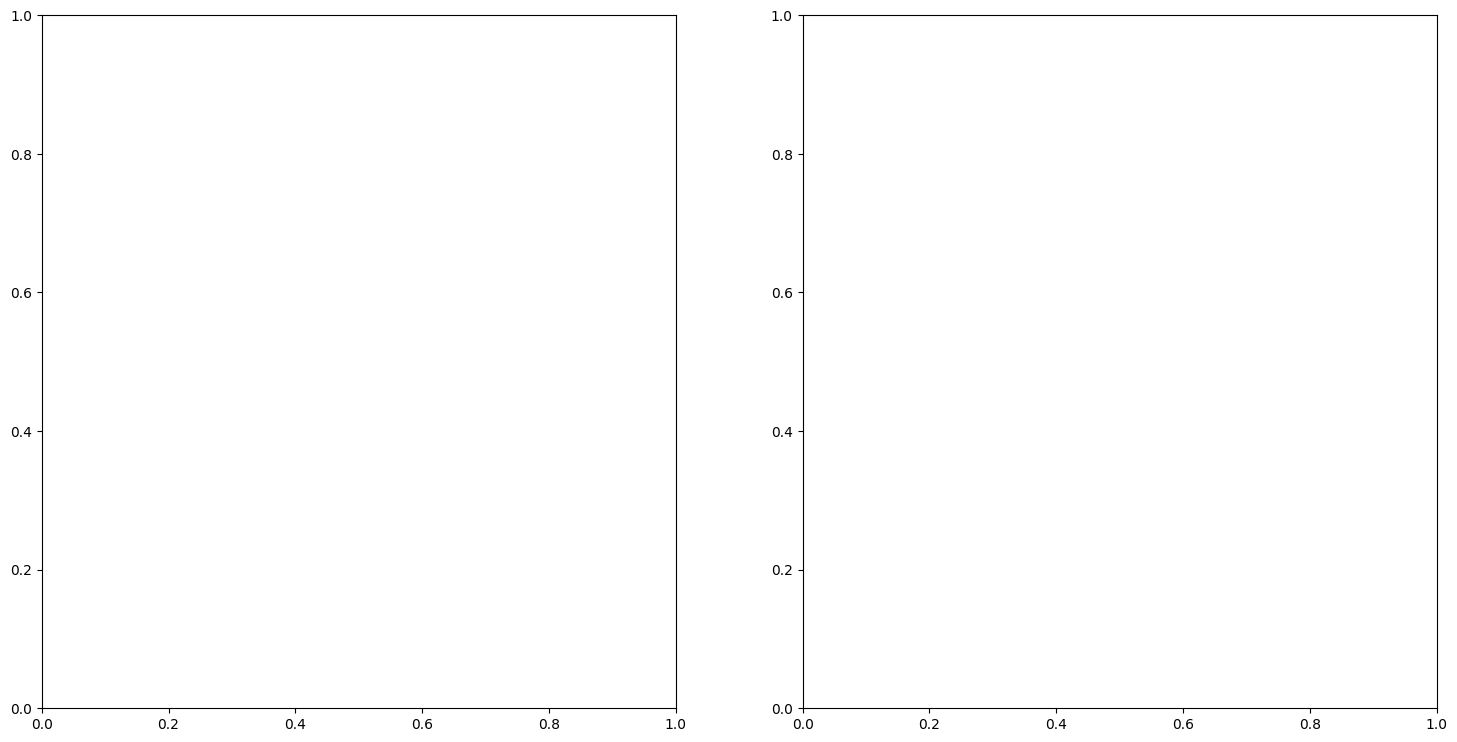

In [ ]:
# ========================================
# MULTI-AGENT SWARM TEST ON MAP_FILE WITH VISUALIZATION
# ========================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

MAP_FILE = next((p for p in ['widjdane_chouali/grid.txt', '../widjdane_chouali/grid.txt'] if Path(p).exists()), 'widjdane_chouali/grid.txt')


def _walkable_rows(grid):
    return [y for y, row in enumerate(grid.grid) if any(row)]


def _walkable_cols(grid, y):
    return [x for x, cell in enumerate(grid.grid[y]) if cell]


def _pick_positions(grid, row, count):
    cols = _walkable_cols(grid, row)
    if len(cols) < count:
        raise ValueError(f"Row {row} only has {len(cols)} walkable cells, need {count}")
    step = max(1, len(cols) // count)
    chosen = []
    for i in range(count):
        chosen.append((cols[min(i * step, len(cols) - 1)], row))
    return chosen


def visualize_swarm(grid, paths, robots, map_file: str):
    """Visualize the grid, obstacles, start/goal locations, and paths computed."""
    obstacle_count = sum(1 for row in grid.grid for cell in row if not cell)
    map_name = map_file.split('/')[-1]
    fig, axes = plt.subplots(1, 2, figsize=(18, 9))
    
    display_width = max((len(row) for row in grid.grid), default=0)
    grid_img = np.ones((grid.height, display_width, 3))
    for y, row in enumerate(grid.grid):
        for x, cell in enumerate(row):
            if not cell:
                grid_img[y, x] = [0.15, 0.15, 0.15]
    
    map_ax = axes[0]
    map_ax.imshow(grid_img, interpolation='nearest')
    map_ax.set_title(f'Grid Layout from {map_name}\n{display_width}x{grid.height} | Obstacles: {obstacle_count}')
    map_ax.set_xticks(np.arange(-0.5, display_width, 1), minor=True)
    map_ax.set_yticks(np.arange(-0.5, grid.height, 1), minor=True)
    map_ax.grid(which='minor', color='black', linestyle='-', linewidth=0.4, alpha=0.25)
    map_ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    
    path_ax = axes[1]
    path_ax.imshow(grid_img, interpolation='nearest')
    for robot in robots:
        path = paths.get(robot.robot_id)
        if path:
            x_coords = [p[0] for p in path]
            y_coords = [p[1] for p in path]
            path_ax.plot(x_coords, y_coords, color=robot.color, alpha=0.85, linewidth=2.5)
            path_ax.scatter(x_coords[0], y_coords[0], color=robot.color, marker='o', s=90, edgecolors='black', zorder=5)
            path_ax.scatter(x_coords[-1], y_coords[-1], color=robot.color, marker='X', s=90, edgecolors='black', zorder=5)
            path_ax.text(x_coords[0], y_coords[0], f' {robot.robot_id}', fontsize=8, color='black', va='bottom')
    
    path_ax.set_title(f'Swarm Paths on {map_name} ({len(robots)} Agents)')
    path_ax.set_xticks(np.arange(-0.5, display_width, 1), minor=True)
    path_ax.set_yticks(np.arange(-0.5, grid.height, 1), minor=True)
    path_ax.grid(which='minor', color='black', linestyle='-', linewidth=0.4, alpha=0.25)
    path_ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Start', markerfacecolor='grey', markersize=9, markeredgecolor='black'),
        Line2D([0], [0], marker='X', color='w', label='Goal', markerfacecolor='grey', markersize=9, markeredgecolor='black')
    ]
    path_ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()


def run_swarm_test():
    test_grid = GridEnvironment(MAP_FILE)
    print(f"Loaded map: {MAP_FILE}")
    print(f"Grid size: {test_grid.width}x{test_grid.height}")
    print(f"Obstacle cells: {sum(1 for row in test_grid.grid for cell in row if not cell)}")
    
    walkable_rows = _walkable_rows(test_grid)
    if len(walkable_rows) < 2:
        raise ValueError("Map needs at least two walkable rows for this swarm test")
    
    start_row = walkable_rows[0]
    goal_row = walkable_rows[-1]
    start_positions = _pick_positions(test_grid, start_row, 10)
    goal_positions = list(reversed(_pick_positions(test_grid, goal_row, 10)))
    
    robots_swarm = []
    colors = [plt.cm.turbo(i / 9) for i in range(10)]
    
    for i in range(10):
        robots_swarm.append(Robot(i, test_grid, start_positions[i], goal_positions[i], colors[i]))
        
    print(f"Initialized {len(robots_swarm)} agents in the maze.")
    
    planner = IndependentAStarPlanner(test_grid)
    detector = ConflictDetector()
    
    start_time = time.time()
    paths = planner.plan_all_robots(robots_swarm)
    elapsed = time.time() - start_time
    
    print("\n--- Planning Results ---")
    print(f"Time Taken: {elapsed:.4f} seconds")
    successful_paths = sum(1 for p in paths.values() if p is not None)
    print(f"Paths successfully calculated: {successful_paths} out of {len(robots_swarm)}")
    
    if successful_paths > 0:
        makespan = calculate_makespan(paths)
        flowtime = calculate_flowtime(paths)
        print(f"Overall Makespan: {makespan}")
        print(f"Overall Flowtime: {flowtime}")
    else:
        print("No valid paths were found on this map.")
    
    valid_paths = {k: v for k, v in paths.items() if v}
    conflict_count = detector.count_conflicts(valid_paths) if valid_paths else 0
    print(f"Total Conflicts Detected (Since they are independent and unaware): {conflict_count}")
    
    print("\nGenerating visualization...")
    visualize_swarm(test_grid, paths, robots_swarm, MAP_FILE)
    
run_swarm_test()